# Validating VRTI: Point Cloud Analysis and Human Perception in Paleontological Documentation

**Project Overview**
This notebook presents a comprehensive analytical workflow to evaluate and compare the performance of two digital documentation methodologies: Traditional RTI (Reflectance Transformation Imaging) and VRTI (Virtual RTI, derived from 3D structured light scanning).
The study focuses on how visualization mediums affect human perception and manual tracing accuracy. By converting student-produced tracings into spatial data, we implement a custom Python pipeline to quantify geometric precision, interpretative consistency, and lighting preferences.

For a detailed breakdown of the experimental design, participant recruitment, and the step-by-step procedure, please refer to our official protocol:

**[Experimental Protocol on Protocols.io](https://www.protocols.io/view/comparative-assessment-protocol-of-readability-usi-kqdg3m1mzl25/v1)**


**Workflow structure:**
1. Data Conversion: Point Cloud Generation from Raster Tracings
2. Quantitative Spatial Metrics and Data Aggregation
3. Statistical Validation and Comparative Visualization
4. Qualitative Expert Evaluation
5. Integrating Interpretative Data: Lighting Perspective
6. Conclusions 

**Disclaimer**: The Python code in this notebook was developed with the assistance of AI tools (LLMs) to ensure code efficiency and standardization.

In [15]:
# Importing the libraries needed for the entire workflow
from pathlib import Path
import cv2
import numpy as np
import os
from scipy.spatial import cKDTree
import csv
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
import scipy.stats as stats

# SECTION 1: Point Cloud Generation from Raster Tracings

The goal of this first step is to convert the manual tracings (PNG images) into spatial data (XYZ point clouds). This process digitizes the interpretative work of the students, allowing for a mathematical comparison of paleontological features.
- **Logic**: The script scans images for Green (Footprint - Task A) and Yellow (Detail - Task B) pixels using BGR color masks.
- **Coordinate transformation**: It maps pixel coordinates (u, v) to spatial coordinates (x, y, z). Since image rows increase downwards, the **Y** axis is inverted (-Y) to maintain correct orientation.
- **Automation**: The process is repeated for RTI, VRTI, and Ground Truth (GT) folders to ensure a standardised dataset across all experimental conditions.

In [2]:
# Configuring paths
base_dir = Path.cwd() / "dataset"

rti_dir = os.path.join(base_dir, "images_rti")
vrti_dir = os.path.join(base_dir, "images_vrti")
gt_path = os.path.join(base_dir, "gt", "1943_groundtruth_perimetro.png")
output_dir_rti = os.path.join(base_dir, "pointclouds_rti")
output_dir_vrti = os.path.join(base_dir, "pointclouds_vrti")

os.makedirs(output_dir_rti, exist_ok=True)
os.makedirs(output_dir_vrti, exist_ok=True)

# === FUNCTION ===
def image_to_pointcloud(image_path, output_path):
    img = cv2.imread(image_path)

    # OpenCV uses BGR
    b, g, r = img[:,:,0], img[:,:,1], img[:,:,2]

    # Tolerance for anti-aliasing
    tol = 10
    
    # Identify the green of the footprint (a)
    mask_green = (
        (r <= tol) &
        (g >= 255 - tol) &
        (b <= tol)
    )
    
    # Identify the yellow of the footprint detail (b)
    mask_yellow = (
        (r >= 255 - tol) &
        (g >= 255 - tol) &
        (b <= tol)
    )

    combined_mask = mask_green | mask_yellow

    points = np.column_stack(np.where(combined_mask))

    if points.size == 0:
        print(f"No points found in {image_path}")
        return

    # Conversion from PNG to XYZ
    xyz = np.zeros((points.shape[0], 3))
    xyz[:, 0] = points[:, 1]   # X = column
    xyz[:, 1] = -points[:, 0]   # Y = inverted axis 
    xyz[:, 2] = 0               # Z

    # Save
    np.savetxt(output_path, xyz, fmt="%.3f")

# Process RTI
for filename in os.listdir(rti_dir):
    if not filename.lower().endswith(".png"):
        continue

    input_path = os.path.join(rti_dir, filename)

    name = os.path.splitext(filename)[0] + "_pointcloud"
    output_path = os.path.join(output_dir_rti, name + ".xyz")

    print(f"Processing {filename}")
    image_to_pointcloud(input_path, output_path)

# Process Ground Truth
gt_output_rti = os.path.join(output_dir_rti, "groundtruth_pointcloud.xyz")
image_to_pointcloud(gt_path, gt_output_rti)

print("\nAll files saved in /pointclouds_rti")

# Process VRTI
for filename in os.listdir(vrti_dir):
    if not filename.lower().endswith(".png"):
        continue

    input_path = os.path.join(vrti_dir, filename)

    name = os.path.splitext(filename)[0] + "_VRTI_pointcloud"
    output_path = os.path.join(output_dir_vrti, name + ".xyz")

    print(f"Processing {filename}")
    image_to_pointcloud(input_path, output_path)

# Process Ground Truth
gt_output_vrti = os.path.join(output_dir_vrti, "groundtruth_pointcloud.xyz")
image_to_pointcloud(gt_path, gt_output_vrti)

print("\nAll files saved in /pointclouds_vrti")

Processing Studente 1(a)_RTI.png
Processing Studente 1(b)_RTI.png
Processing Studente 10(a)_RTI.png
Processing Studente 10(b)_RTI.png
Processing Studente 11(a)_RTI.png
Processing Studente 11(b)_RTI.png
Processing Studente 12(a)_RTI.png
Processing Studente 12(b)_RTI.png
Processing Studente 13(a)_RTI.png
Processing Studente 13(b)_RTI.png
Processing Studente 14(a)_RTI.png
Processing Studente 14(b)_RTI.png
Processing Studente 15(a)_RTI.png
Processing Studente 15(b)_RTI.png
Processing Studente 16(a)_RTI.png
Processing Studente 16(b)_RTI.png
Processing Studente 17(a)_RTI.png
Processing Studente 17(b)_RTI.png
Processing Studente 18(a)_RTI.png
Processing Studente 18(b)_RTI.png
Processing Studente 19(a)_RTI.png
Processing Studente 19(b)_RTI.png
Processing Studente 2(a)_RTI.png
Processing Studente 2(b)_RTI.png
Processing Studente 20(a)_RTI.png
Processing Studente 20(b)_RTI.png
Processing Studente 3(a)_RTI.png
Processing Studente 3(b)_RTI.png
Processing Studente 4(a)_RTI.png
Processing Studente 4

# SECTION 2: Quantitative Spatial Metrics and Data Aggregation

**Introduction**
In this stage, we quantify the geometric accuracy of the manual tracings by comparing student point clouds against the Ground Truth (GT). The analysis is performed using a custom Python pipeline that processes each student file, calculates spatial deviations, and exports the results into structured CSV files for both RTI and VRTI datasets.

**Methodological Approach: Unidirectional vs. Bidirectional**
1. **Primary Metric (Unidirectional)**: Following the experimental protocol, where students were instructed to trace only features they deemed reliable, we adopted the Unidirectional RMSE as our primary metric. This approach measures the distance from each student's point to the nearest GT point, evaluating interpretative accuracy without penalizing intentional omissions.
2. **Complementary Analysis (Bidirectional)**: A bidirectional (Chamfer) distance block is included in the script as commented code. This metric considers both accuracy and completeness (penalizing omissions) and remains available for future research or verification purposes.

**Key Components of the Pipeline**:
- **Grid-based Subsampling**: Normalizes point density to ensure that line thickness or total length does not bias the statistical weight of the tracings.
- **cKDTree Efficiency**: Utilizes a space-partitioning data structure for high-speed Nearest Neighbor (NN) searches.
  
**Metric Suite**:
- **RMSE**: Captures overall geometric precision, emphasizing larger deviations.
- **P90**: Identifies the error threshold for 90% of the points, offering a stable view of typical performance.
- **StdDev**: Measures the consistency and regularity of the tracing stroke.

After generating the CSV files, the script prints a statistical summary for each group and task. These values represent the "Mean of Means," providing an immediate overview of the group’s central tendency.

In [3]:
# === FUNCTIONS ===

# === SUBSAMPLING (grid-based) ===
def subsample(points, step=1):
    grid = np.floor(points[:, :2] / step)
    _, idx = np.unique(grid, axis=0, return_index=True)
    return points[idx]

# === NN DISTANCE (UNIDIRECTIONAL: student → GT) ===
def nn_distance(A, B):
    tree = cKDTree(B)
    dist, _ = tree.query(A)
    return dist

# === UNIDIRECTIONAL METRICS ===
def compute_metrics(student, gt):
    d = nn_distance(student, gt)

    rmse = np.sqrt(np.mean(d**2))

    return {
        "mean": np.mean(d),
        "rmse": rmse,
        "std": np.std(d),
        "max": np.max(d),
        "p90": np.percentile(d, 90)
    }
    
# --- OPTIONAL: BIDIRECTIONAL CHAMFER DISTANCE ---
# Uncomment and substitute the script block above to evaluate both accuracy and completeness
#def chamfer_distance(A, B):
    #d1 = nn_distance(A, B)
    #d2 = nn_distance(B, A)

# # Calculating RMSE: Root Mean Square Error ===

    #rmse_d1 = np.sqrt(np.mean(d1**2))
    #rmse_d2 = np.sqrt(np.mean(d2**2))

    #return {
        #"mean": (np.mean(d1) + np.mean(d2)) / 2,
        #"rmse": (rmse_d1 + rmse_d2) / 2,
        #"std": (np.std(d1) + np.std(d2)) / 2,
        #"max": max(np.max(d1), np.max(d2)),
        #"p90": (np.percentile(d1, 90) + np.percentile(d2, 90)) / 2
    #} 
    

# === CONFIGURATION ===
tasks = [("pointclouds_rti", "rti"), ("pointclouds_vrti", "vrti")]
groups = ["(a)", "(b)"]

# === MAIN PROCESSING LOOP (FOR BOTH A (footprint) AND B (detail)) ===
for cloud_folder, suffix in tasks:
    data_dir = os.path.join(base_dir, cloud_folder)
    results_dir = os.path.join(base_dir, f"results_{suffix}")
    gt_path = os.path.join(data_dir, "groundtruth_pointcloud.xyz")

    os.makedirs(results_dir, exist_ok=True)

    print(f"\nSTARTING ANALYSIS FOR: {cloud_folder.upper()}")

    if not os.path.exists(gt_path):
        print(f"Skipping {cloud_folder}: GT not found")
        continue

    # === LOAD & SUBSAMPLE GT ===
    gt = np.loadtxt(gt_path)
    gt = subsample(gt, step=1)

    for group in groups:

        results = []
        clean_group = group.strip('()')
        output_file = os.path.join(results_dir, f"distances_{suffix}_{clean_group}.csv")

# Correct logic: file must contain both "Studente" AND the specific group suffix 
        
        for file in os.listdir(data_dir):
            if "Studente" in file and group in file:

                path = os.path.join(data_dir, file)

                try:
                    student = np.loadtxt(path, dtype=float)

                    if np.isnan(student).any():
                        continue

                    # === SUBSAMPLE STUDENT === Apply subsampling and calculate distances to student data
                    student_sub = subsample(student, step=1)

                    # === COMPUTE METRICS (UNIDIRECTIONAL) ===
                    metrics = compute_metrics(student_sub, gt)

                    results.append([
                        file,
                        metrics["mean"],
                        metrics["rmse"],
                        metrics["std"],
                        metrics["max"],
                        metrics["p90"]
                    ])

                except Exception as e:
                    print(f"Error with {file}: {e}")
                    continue

            # === EXPORT DATA TO CSV ===
        if results:
            with open(output_file, "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(["File", "Mean", "RMSE", "StdDev", "Max", "P90"])
                writer.writerows(results)

            # Display Summary Stats in Notebook
            df = pd.read_csv(output_file)

            summary = {
                "RMSE_mean": df["RMSE"].mean(),
                "P90_mean": df["P90"].mean(),
                "StdDev_mean": df["StdDev"].mean(),
                "Mean_mean": df["Mean"].mean()
            }

            print(f"Analysis saved to output file")
            print(f"GROUP {group} STATS:")

            for k, v in summary.items():
                print(f"  {k}: {v:.4f}")

        else:
            print(f"No files found for group {group}")

print("\nProcessing complete. All CSV files generated in results folders.")


STARTING ANALYSIS FOR: POINTCLOUDS_RTI
Analysis saved to output file
GROUP (a) STATS:
  RMSE_mean: 57.3019
  P90_mean: 96.8610
  StdDev_mean: 42.4218
  Mean_mean: 38.0723
Analysis saved to output file
GROUP (b) STATS:
  RMSE_mean: 67.0464
  P90_mean: 123.8558
  StdDev_mean: 47.4094
  Mean_mean: 47.0578

STARTING ANALYSIS FOR: POINTCLOUDS_VRTI
Analysis saved to output file
GROUP (a) STATS:
  RMSE_mean: 59.7036
  P90_mean: 104.9884
  StdDev_mean: 43.3604
  Mean_mean: 40.5639
Analysis saved to output file
GROUP (b) STATS:
  RMSE_mean: 59.4681
  P90_mean: 105.5432
  StdDev_mean: 37.9667
  Mean_mean: 45.5985

Processing complete. All CSV files generated in results folders.


# SECTION 3: Statistical Validation and Comparative Visualization

**Introduction**
This section determines whether the differences in performance between RTI and VRTI are statistically significant. We first assess the normality of the distributions and then perform a non-parametric comparison.

1. **Normality Testing (Shapiro-Wilk)**
Before comparing the groups, we assess the distribution of the RMSE values. Given our small sample size (N≈20), the **Shapiro-Wilk test** is the most appropriate tool to check for normality.

In [4]:
# === CONFIGURATION ===
base_dir = Path.cwd() / "dataset"
rti_path_a = base_dir / "results_rti" / "distances_rti_a.csv"
vrti_path_a = base_dir / "results_vrti" / "distances_vrti_a.csv"
rti_path_b = base_dir / "results_rti" / "distances_rti_b.csv"
vrti_path_b = base_dir / "results_vrti" / "distances_vrti_b.csv"

# Load RMSE columns
r_rmse_a = pd.read_csv(rti_path_a)["RMSE"].dropna()
v_rmse_a = pd.read_csv(vrti_path_a)["RMSE"].dropna()
r_rmse_b = pd.read_csv(rti_path_b)["RMSE"].dropna()
v_rmse_b = pd.read_csv(vrti_path_b)["RMSE"].dropna()

# === SHAPIRO-WILK TEST ===
def check_normality(data, label):
    stat, p = shapiro(data)
    print(f"--- {label} ---")
    print(f"Statistics: {stat:.4f}, p-value: {p:.5f}")
    if p < 0.05:
        print("RESULT: Data is NOT normally distributed (Reject H0)")
    else:
        print("RESULT: Data follows a Normal distribution (Fail to reject H0)")
    print("-" * 30)

check_normality(r_rmse_a, "RTI RMSE (Task A)")
check_normality(v_rmse_a, "VRTI RMSE (Task A)")
check_normality(r_rmse_b, "RTI RMSE (Task B)")
check_normality(v_rmse_b, "VRTI RMSE (Task B)")

--- RTI RMSE (Task A) ---
Statistics: 0.8876, p-value: 0.02434
RESULT: Data is NOT normally distributed (Reject H0)
------------------------------
--- VRTI RMSE (Task A) ---
Statistics: 0.8703, p-value: 0.01462
RESULT: Data is NOT normally distributed (Reject H0)
------------------------------
--- RTI RMSE (Task B) ---
Statistics: 0.9647, p-value: 0.64168
RESULT: Data follows a Normal distribution (Fail to reject H0)
------------------------------
--- VRTI RMSE (Task B) ---
Statistics: 0.9892, p-value: 0.99757
RESULT: Data follows a Normal distribution (Fail to reject H0)
------------------------------


**Note on Statistical Choice:**
Although the **Shapiro-Wilk test** indicated a normal distribution for the Task B datasets (p > 0.05), the **Mann-Whitney U Test** was maintained across all comparisons to ensure methodological consistency throughout the study. Furthermore, non-parametric testing is preferred for small sample sizes (n ≈ 20) as it provides a more robust and conservative estimate, ensuring that the analysis remains reliable even if the underlying population distribution cannot be fully guaranteed.

**2. Data Comparison and Visualization****
To visualize the performance spread, we use **Boxplots** overlaid with **Jittered Scatter Points**. This combination allows us to see the central tendency (Median) while simultaneously observing individual variability and potential outliers.
  - **Boxes**: Represent the distribution and median of the RMSE.
  - **Jitter Points**: Individual student results are plotted to visualize the spread and identify outliers.
  - **P-Value interpretation**: Calculated via the Mann-Whitney U test, a value > 0.05 confirms that the difference between RTI and VRTI is not statistically significant.


--- Results for Group A ---
RTI mean RMSE: 57.3019 | VRTI mean RMSE: 59.7036
p-value: 0.36115
The comparison is not statistically significant


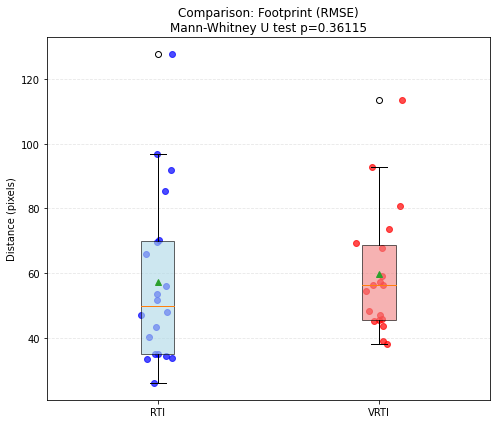


--- Results for Group B ---
RTI mean RMSE: 67.0464 | VRTI mean RMSE: 59.4681
p-value: 0.25514
The comparison is not statistically significant


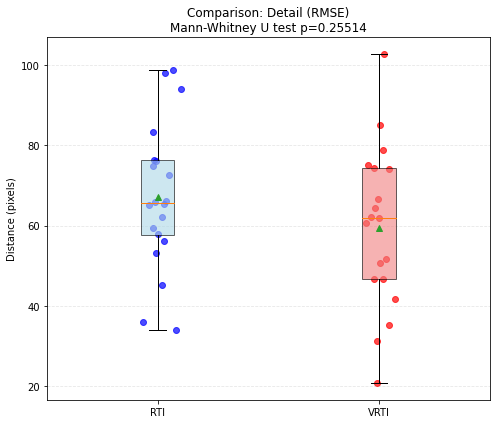


Comparison analysis completed.


In [5]:
# === CONFIGURATION ===
results_rti_dir = "dataset/results_rti"
results_vrti_dir = "dataset/results_vrti"
groups = ["a", "b"]
    
for group in groups:
    # Build file paths
    rti_path = os.path.join(results_rti_dir, f"distances_rti_{group}.csv")
    vrti_path = os.path.join(results_vrti_dir, f"distances_vrti_{group}.csv")
    
    if not os.path.exists(rti_path) or not os.path.exists(vrti_path):
        print(f"Skipping group {group}: files not found.")
        continue

    # === LOAD AND CLEAN ===
    rti_df = pd.read_csv(rti_path)
    vrti_df = pd.read_csv(vrti_path)
    
    r = pd.to_numeric(rti_df["RMSE"], errors="coerce").dropna()
    v = pd.to_numeric(vrti_df["RMSE"], errors="coerce").dropna()

    # === STATISTICAL TEST (Mann-Whitney U) ===
    # Using this as it's robust for small samples (19-20)
    stat, p = mannwhitneyu(r, v)
    print(f"\n--- Results for Group {group.upper()} ---")
    print(f"RTI mean RMSE: {r.mean():.4f} | VRTI mean RMSE: {v.mean():.4f}")
    print(f"p-value: {p:.5f}")

    # === PLOTTING ===
    plt.figure(figsize=(7, 6))
    
    # Boxplot
    box = plt.boxplot([r, v], labels=["RTI", "VRTI"], showmeans=True, patch_artist=True)
    #if 'labels' doesn't work or it is not recognized by your MatPlotLib version, use 'tick_labels' instead
    
    # Styling boxes
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Add individual points (Jitter)
    plt.scatter(np.random.normal(1, 0.04, size=len(r)), r, alpha=0.7, color='blue', label='RTI Samples')
    plt.scatter(np.random.normal(2, 0.04, size=len(v)), v, alpha=0.7, color='red', label='VRTI Samples')

    # Labels and titles
    group_title = "Footprint" if group == "a" else "Detail"
    plt.ylabel("Distance (pixels)")
    plt.title(f"Comparison: {group_title} (RMSE)\nMann-Whitney U test p={p:.5f}")
    
    # Highlight significance
    if p < 0.05:
        plt.text(1.5, max(r.max(), v.max()), "Statistically Significant", 
                 ha='center', color='darkred', fontweight='bold')
    else:
        print("The comparison is not statistically significant")

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Optional: save the plot
    # plt.savefig(f"comparison_plot_{group}.png")
    
    plt.show()

print("\nComparison analysis completed.")


**Note on Quantitative Results**
Before integrating the expert's feedback, the spatial analysis of the point clouds provides several key insights:

- **Technological Transparency**: The lack of statistical significance (p>0.05) across all tasks suggests a high level of "technological transparency." Students were able to perceive and document paleontological features with comparable geometric precision using both traditional RTI and the VRTI-generated models.
- **Metric Consistency**: It is noteworthy that this lack of statistical difference holds true for both unidirectional and bidirectional (Chamfer) analyses. Regardless of the metric used—whether focusing strictly on accuracy or including penalties for completeness—the comparison consistently yields p > 0.05, reinforcing the conclusion that both mediums are functionally equivalent.
- **Precision in Detail (Task B)**: Notably, in the detail-tracing task, the VRTI group achieved a slightly lower mean RMSE than the RTI group. This suggests that the virtual rendering from high-resolution 3D scans is highly effective for documenting micro-morphological features, as it does not introduce geometric distortions that would otherwise increase the error.
- **Individual Variability:** The jittered scatter plots reveal that human interpretative variability is more influential than the visualization medium itself. The wide spread of individual RMSE values, especially in Task B, confirms that paleontological feature recognition remains a subjective and challenging task, regardless of the digital tool used.

# SECTION 4: Qualitative Expert Evaluation

**Introduction**
To validate the quantitative results, a qualitative assessment was conducted. A paleontological domain expert performed a blind review of all student tracings, assigning a score from 1 (poor) to 5 (optimal) based on a Likert scale.

This qualitative layer is essential to determine if mathematical precision (RMSE) translates into professional interpretative quality, helping to identify whether certain visualization mediums influence the expert's perception of the documentation.

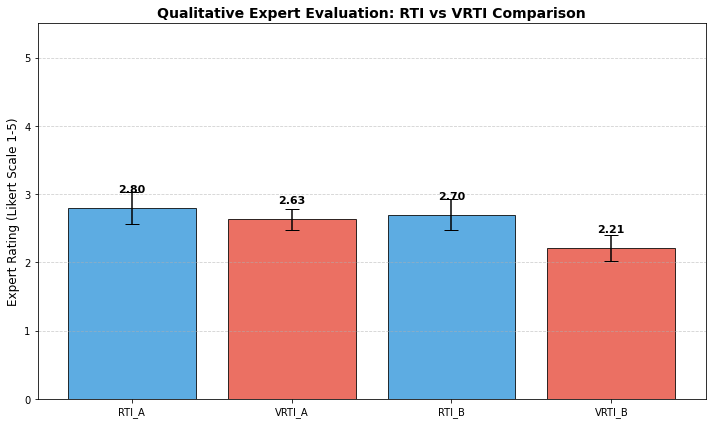

In [6]:
## === 1. DATA LOADING ===

file_path = "dataset/expert_evaluations/expert_evaluations.csv" 
df = pd.read_csv(file_path)

# CLEANING: Removing any invisible leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

# === 2. DEFINE CATEGORIES ===
# These must match the cleaned column names exactly
categories = ['RTI_A', 'VRTI_A', 'RTI_B', 'VRTI_B']

try:
    means = df[categories].mean()
    errors = df[categories].sem()

    # === 3. Visualization ===
    plt.figure(figsize=(10, 6))
    colors = ['#3498db', '#e74c3c', '#3498db', '#e74c3c'] 

    bars = plt.bar(categories, means, yerr=errors, capsize=7, color=colors, edgecolor='black', alpha=0.8)

    plt.ylabel('Expert Rating (Likert Scale 1-5)', fontsize=12)
    plt.title('Qualitative Expert Evaluation: RTI vs VRTI Comparison', fontsize=14, fontweight='bold')
    plt.ylim(0, 5.5)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

except KeyError as e:
    print(f"\nERROR: Python doesn't find the columns. The error is: {e}")
    print("Check if in the CSV names are wrote in uppercase or lowercase or with underscore (i.e. rti_perimetro)")

**Note on Qualitative Results**
- **Triangulation:** The comparison between these scores and the previous RMSE boxplots allows for data triangulation.
- **Observations:** While Task A shows stability across platforms, the lower score in VRTI_B reflects a more "cautious" or "fragmented" tracing style, which the expert may perceive as less confident despite its equivalent geometric accuracy compared to RTI.

# SECTION 5: Integrating Interpretative Data: Lighting Perspective

**Introduction**
As a secondary and integrative layer of the evaluation framework, we analyze the lighting coordinates (X, Y) selected by participants as the "optimal perspective" for feature recognition. This stage evaluates visual perception by determining if the VRTI rendering influences the user's spatial behavior within the light dome compared to traditional RTI.

**Statistical Validation (Shapiro-Wilk)**
Before comparing the groups, we test the normality of the coordinates.

In [7]:
# === Configuring .csv paths ===
results_rti_dir = "dataset/results_rti"
results_vrti_dir = "dataset/results_vrti"

path_rti = os.path.join(results_rti_dir, "RTI_light.csv")
path_vrti = os.path.join(results_vrti_dir, "VRTI_light.csv")

# === LOAD DATA ===
df_rti = pd.read_csv(path_rti)
df_vrti = pd.read_csv(path_vrti)

In [8]:
# === SHAPIRO-WILK TEST FOR LIGHTING ===
def check_lighting_normality(df_rti, df_vrti):
    print("--- NORMALITY TEST (SHAPIRO-WILK) FOR LIGHTING PERSPECTIVE ---")
    for axis in ['X', 'Y']:
        # Extract values
        r_vals = df_rti[axis].dropna()
        v_vals = df_vrti[axis].dropna()
        
        # RTI Test
        stat_r, p_r = shapiro(r_vals)
        # VRTI Test
        stat_v, p_v = shapiro(v_vals)
        
        print(f"\nAxis {axis}:")
        print(f"  RTI  -> p-value: {p_r:.5f} | {'Normal' if p_r > 0.05 else 'NOT Normal'}")
        print(f"  VRTI -> p-value: {p_v:.5f} | {'Normal' if p_v > 0.05 else 'NOT Normal'}")
    print("-" * 60)

# Run test
check_lighting_normality(df_rti, df_vrti)

--- NORMALITY TEST (SHAPIRO-WILK) FOR LIGHTING PERSPECTIVE ---

Axis X:
  RTI  -> p-value: 0.00952 | NOT Normal
  VRTI -> p-value: 0.00144 | NOT Normal

Axis Y:
  RTI  -> p-value: 0.27704 | Normal
  VRTI -> p-value: 0.06129 | Normal
------------------------------------------------------------


The **Shapiro-Wilk test** confirmed that the lighting coordinates for the X-axis were **not normally distributed (p < 0.01)**, indicating a significant skew in participant preferences. Conversely, the Y-axis displayed a normal distribution (p > 0.05). To maintain analytical consistency across both spatial dimensions and to account for the non-parametric nature of the X-axis data, the **Mann-Whitney U Test** was applied to the entire lighting dataset. This ensures a robust comparison that is insensitive to the observed asymmetries in the lighting dome distribution.

--- LIGHTING COORDINATES COMPARISON ---
  Axis  RTI_Mean  VRTI_Mean  RTI_Median  VRTI_Median   p-value
0    X      0.10  -0.063158        0.25         -0.3  0.366689
1    Y     -0.05  -0.200000       -0.15         -0.3  0.343941


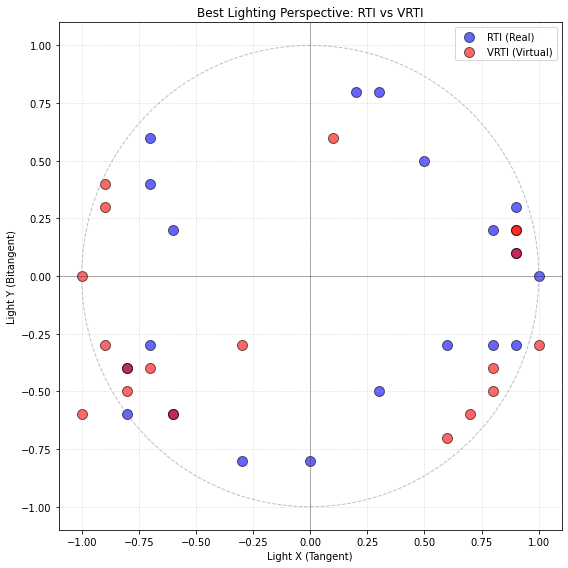

In [9]:
# === 1. STATISTICAL COMPARISON (Step-by-Step) ===
# Descriptive Statistics and Mann-Whitney U Test
# Comparing X (Tangent) and Y (Bitangent) coordinates for RTI and VRTI

def compare_lights(df1, df2, label1="RTI", label2="VRTI"):
    stats = []
    for axis in ['X', 'Y']:
        val1 = df1[axis].dropna()
        val2 = df2[axis].dropna()
        
        # Calculate Mean and Median
        m1, med1 = val1.mean(), val1.median()
        m2, med2 = val2.mean(), val2.median()
        
        # Mann-Whitney U test to see if the choice distribution differs
        stat, p = mannwhitneyu(val1, val2)
        
        stats.append({
            "Axis": axis,
            f"{label1}_Mean": m1, f"{label2}_Mean": m2,
            f"{label1}_Median": med1, f"{label2}_Median": med2,
            "p-value": p
        })
    return pd.DataFrame(stats)

comparison_results = compare_lights(df_rti, df_vrti)
print("--- LIGHTING COORDINATES COMPARISON ---")
print(comparison_results)

# === 2. VISUALIZATION (Pattern Recognition) ===
# Spatial Distribution of Light Choices
# The plot shows student selections within the RTI hemispherical domain (unit circle).

plt.figure(figsize=(8, 8))

# Plot RTI choices
plt.scatter(df_rti['X'], df_rti['Y'], color='blue', alpha=0.6, label='RTI (Real)', s=100, edgecolors='k')

# Plot VRTI choices
plt.scatter(df_vrti['X'], df_vrti['Y'], color='red', alpha=0.6, label='VRTI (Virtual)', s=100, edgecolors='k')

# Drawing the RTI domain limit (usually a unit circle)
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5)
plt.gca().add_patch(circle)

# Formatting the plot
plt.axhline(0, color='black', linewidth=1, alpha=0.3)
plt.axvline(0, color='black', linewidth=1, alpha=0.3)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Light X (Tangent)")
plt.ylabel("Light Y (Bitangent)")
plt.title("Best Lighting Perspective: RTI vs VRTI")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Notes on Lighting Perspective Results**
The resulting scatter plots visualize the spatial distribution and confirm the subjective nature of paleontological feature recognition.

1. **High Dispersion (Subjectivity)**: the scatter plot reveals a high degree of dispersion. There is no single "cluster" or "magic point" of light; instead, students found the details visible from many different angles. This suggests that the perception of the artifact's micro-topography is highly individual.
2. **Preference for grazing light**: Most selections (both RTI and VRTI) are located near the edge of the circle (values approaching 1.0 or -1.0). This confirms a natural preference for low-angle grazing light, which maximizes the casting of micro-shadows, making the footprint's details more legible.
3. **Statistical equivalency**: The p-values (0.36 and 0.34) are significantly above the 0.05 threshold. This is a crucial finding: the visualization of the footprint, regardless of the technique used to obtain it (RTI and VRTI) do not statistically influence the lighting choice. Students trying the VRTI-generated model perceived the volumes and surface characteristics in the same way as those trying the RTI-generated model.
4. **Metrics**: While the Means show slight differences, the Medians remain relatively central. Given the high variance (dispersion), the Scatter Plot is the most effective tool to demonstrate that both groups explored the light dome with similar "spatial behavior.

## Correlation Analysis between Lighting Behavior and Interpretation Performance

To address the hypothesis that specific lighting strategies (e.g., preference for grazing light) might influence user interpretation accuracy, we analyze the correlation between the participants' selected lighting positions and their final tracing errors (RMSE). 

We compute the **Euclidean distance** of each selected light coordinate $(X, Y)$ from the center of the virtual dome $(0,0)$. A larger distance represents a light source closer to the horizon (grazing light). We then apply a **Spearman rank correlation analysis** between this distance and the RMSE values across all datasets (RTI and VRTI for both tasks A and B). 

This non-parametric test determines whether individual variations in interactive lighting manipulation directly impact the quality and accuracy of the resulting tracing.

In [18]:
# Configuration of file paths for automated analysis
datasets = [
    {
        "name": "RTI (A)",
        "rmse_path": "dataset/results_rti/distances_rti_a.csv",
        "light_path": "dataset/results_rti/RTI_light.csv"
    },
    {
        "name": "RTI (B)",
        "rmse_path": "dataset/results_rti/distances_rti_b.csv",
        "light_path": "dataset/results_rti/RTI_light.csv"
    },
    {
        "name": "VRTI (A)",
        "rmse_path": "dataset/results_vrti/distances_vrti_a.csv",
        "light_path": "dataset/results_vrti/VRTI_light.csv"
    },
    {
        "name": "VRTI (B)",
        "rmse_path": "dataset/results_vrti/distances_vrti_b.csv",
        "light_path": "dataset/results_vrti/VRTI_light.csv"
    }
]

print("=== SPEARMAN CORRELATION ANALYSIS (Light Distance vs RMSE) ===\n")

for ds in datasets:
    try:
        # 1. Load CSV files
        df_rmse = pd.read_csv(ds["rmse_path"])
        df_light = pd.read_csv(ds["light_path"])
        
        # 2. Extract Student ID from the 'File' column to allow merging
        df_rmse['Student'] = df_rmse['File'].str.extract(r'(\d+)').astype(int)
        
        # 3. Merge datasets on the common 'Student' identifier
        df_merged = pd.merge(df_rmse, df_light, on="Student")
        
        if df_merged.empty:
            print(f"[{ds['name']}] Error: No matching Student IDs found.")
            continue
            
        # 4. Compute Euclidean distance of the light from the dome center (grazing light index)
        df_merged['Light_Distance'] = np.sqrt(df_merged['X']**2 + df_merged['Y']**2)
        
        # 5. Compute Spearman Rank Correlation (Light Distance vs RMSE)
        corr_dist, p_dist = stats.spearmanr(df_merged['Light_Distance'], df_merged['RMSE'])
        
        # 6. Print formatted results
        print(f" {ds['name']}:")
        print(f"   Sample size (N): {len(df_merged)}")
        print(f"   Spearman r:      {corr_dist:.3f}")
        print(f"   p-value:         {p_dist:.3f}")
        print(f"   Significant?   {'YES (p < 0.05)' if p_dist < 0.05 else 'NO (p >= 0.05)'}")
        print("-" * 50)
        
    except Exception as e:
        print(f"Error processing {ds['name']}: {str(e)}")
        print("-" * 50)

=== SPEARMAN CORRELATION ANALYSIS (Light Distance vs RMSE) ===

 RTI (A):
   Sample size (N): 20
   Spearman r:      -0.171
   p-value:         0.471
   Significant?   NO (p >= 0.05)
--------------------------------------------------
 RTI (B):
   Sample size (N): 20
   Spearman r:      -0.121
   p-value:         0.610
   Significant?   NO (p >= 0.05)
--------------------------------------------------
 VRTI (A):
   Sample size (N): 19
   Spearman r:      0.119
   p-value:         0.628
   Significant?   NO (p >= 0.05)
--------------------------------------------------
 VRTI (B):
   Sample size (N): 19
   Spearman r:      -0.205
   p-value:         0.400
   Significant?   NO (p >= 0.05)
--------------------------------------------------


**Interpretation of Correlation Results**
The execution of the Spearman rank correlation yields high $p$-values across all four experimental cohorts (well above the standard $\alpha = 0.05$ threshold):
* **RTI task A and B:** $p = 0.471$ and $p = 0.610$
* **VRTI task A and B:** $p = 0.628$ and $p = 0.400$

These statistical outputs demonstrate that **the results are not significant**. There is no meaningful correlation between the grazing light index (distance from the dome center) and the tracing error (RMSE). 

From a user-experience and system-validation perspective, this is a highly positive outcome. It suggests that a user's final tracing performance is independent of their individual lighting manipulation tactics. Whether a participant preferred highly raking light or more central illumination, the cognitive and perceptual affordances provided by both the RTI and VRTI platforms remained uniformly stable and effective, effectively ruling out lighting exploration behavior as a confounding variable.

# SECTION 6: Conclusions

This integrated analysis leads to three fundamental conclusions regarding the use of Virtual RTI (VRTI) as a tool for paleontological study:
1. **Technological Transparency**: Both quantitative (RMSE) and qualitative (Expert scores) analyses demonstrate that VRTI is as reliable as traditional RTI. The lack of statistical significance (p > 0.05) across all tasks suggests that the virtual rendering from high-resolution 3D scans does not distort the perception or the documentation of trace fossils.
2. **Human Factor vs. Technology**: The high dispersion observed in both the tracing accuracy and the lighting selection confirms that individual interpretative variability seems to be the dominant factor in paleontological documentation. The visualization medium (Real vs. Virtual) is indicated as secondary to the observer's experience and subjective perception of morphological features.
3. **Efficiency of the VRTI Pipeline**: The study support the validation of the custom pipeline used to generate VRTI files. Despite being a synthetic reconstruction, the virtual model effectively preserves the micro-topographical information necessary for professional-grade documentation, offering a flexible and portable alternative for in-situ or lab-based research.

**Summary Statement**
The results confirm that the transition from traditional RTI to 3D-derived VRTI is seamless for the operator. While the expert's qualitative scores suggested a slightly more 'hesitant' interpretation in the VRTI detail task, the quantitative bidirectional metrics confirm that omissions were consistent across both groups. This indicates that the difficulty of the paleontological detail affected participants equally, regardless of the technology used, further proving the technological transparency of the VRTI medium.
